Loading wrist temperature data...


Loading: 100%|██████████| 93/93 [00:06<00:00, 15.41it/s]


Total day-sessions loaded: 1129


C:\Users\Attioui Hicham\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(



Cluster 0: High temperature (mean = -0.460 °C)
Cluster 1: Low temperature  (mean = -1.767 °C)
Cluster sizes: {0: 714, 1: 415}


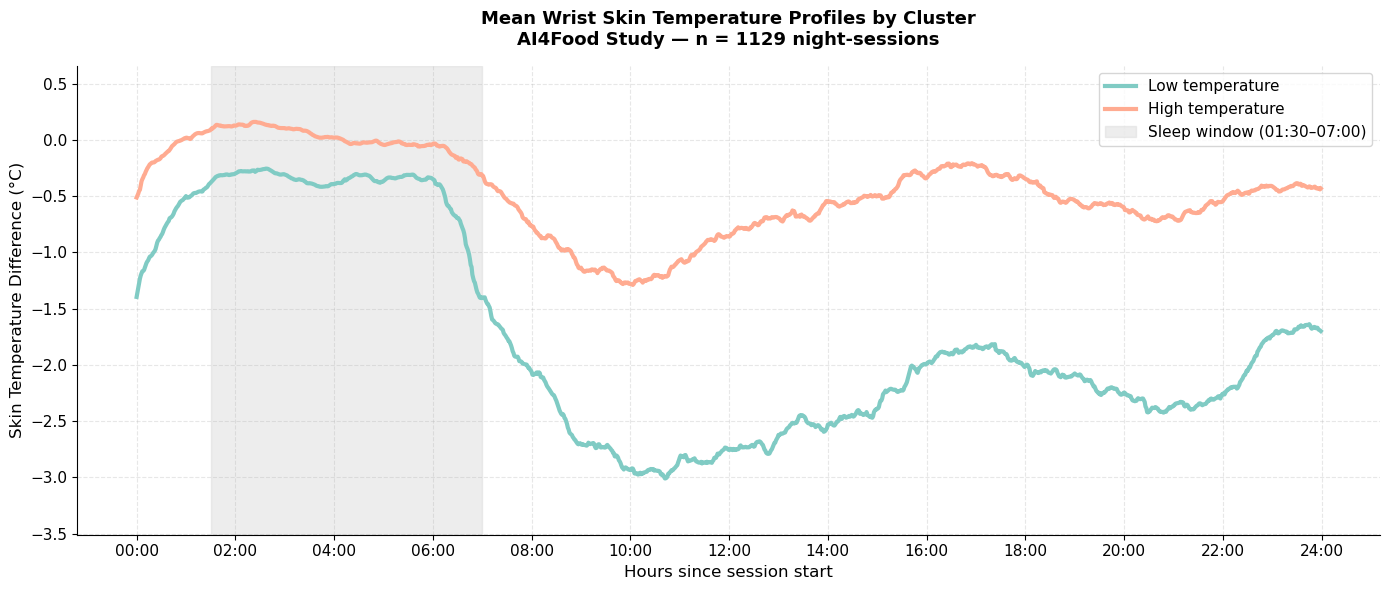

Figure saved: figures/temperature_cluster_curves.png


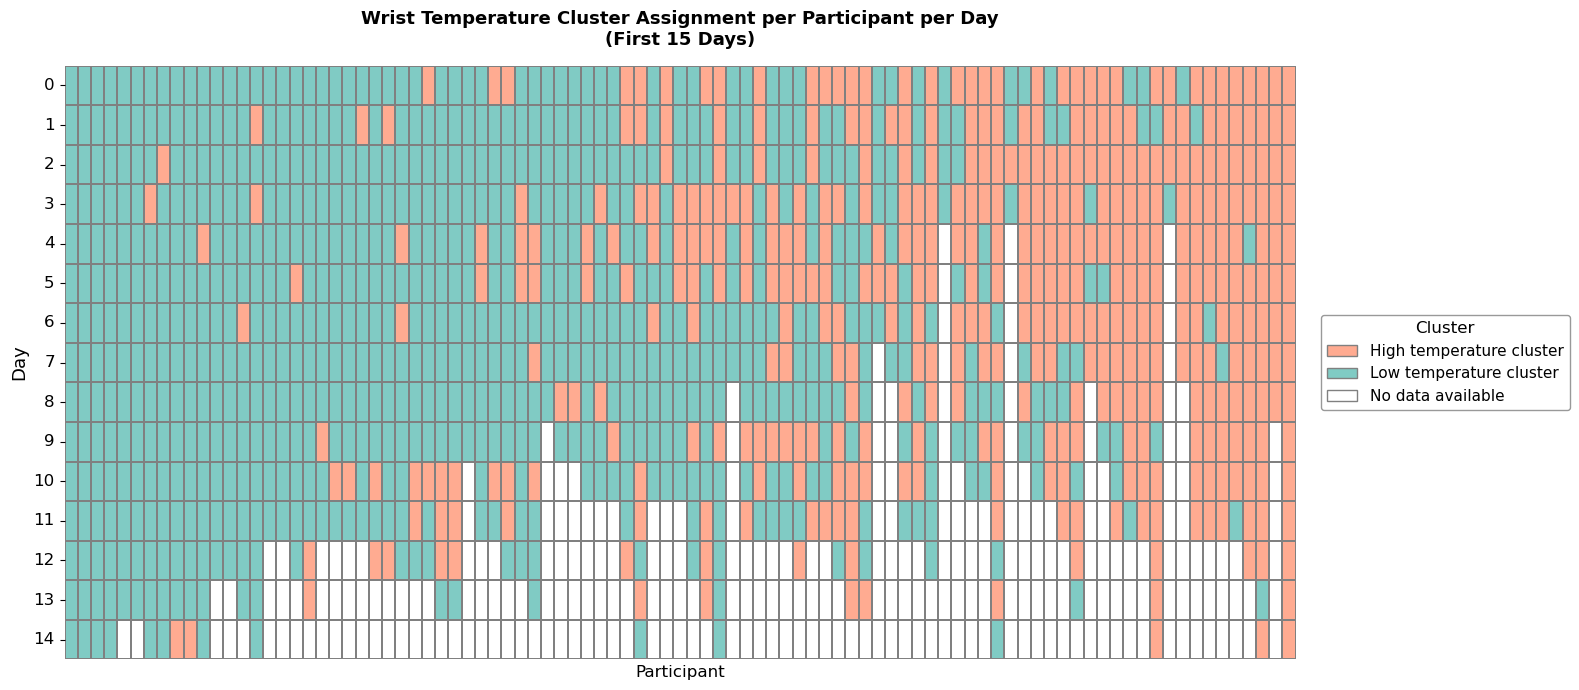

Figure saved: figures/temperature_cluster_heatmap.png

Cluster assignments saved.
Total rows: 1302 | Participants: 93


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

os.makedirs("figures", exist_ok=True)
os.makedirs("data", exist_ok=True)


# CONFIGURATION


GROUP1_FOLDER = "data/DS8_Wrist_temp/group_1"
GROUP2_FOLDER = "data/DS8_Wrist_temp/group_2"

N_CLUSTERS  = 2
MIN_DAYS    = 100      
MAX_DAYS    = 15       
SLEEP_START = "01:30"
SLEEP_END   = "07:00"
COLOR_HIGH  = "#FFAB91"
COLOR_LOW   = "#80CBC4"


# LOAD AND PROCESS DATA


def load_temperature_data(group1_path, group2_path):
    """
    Load wrist temperature data for both groups.
    Returns aligned profile matrix and session ID list.
    """
    import glob

    group1_files = [f for f in os.listdir(group1_path) if f.endswith("_wrist_temperature.csv")]
    group2_files = [f for f in os.listdir(group2_path) if f.endswith("_wrist_temperature.csv")]

    all_files = (
        [(os.path.join(group1_path, f), f"group_1_{f.split('_')[0]}") for f in group1_files] +
        [(os.path.join(group2_path, f), f"group_2_{f.split('_')[0]}") for f in group2_files]
    )

    all_profiles = []
    all_ids      = []
    day_counts   = {}

    for file_path, participant_id in tqdm(all_files, desc="Loading"):
        try:
            df = pd.read_csv(file_path)
            df['timestamp'] = pd.to_datetime(df['timestamp'])
            df = df.sort_values('timestamp')
            df['date'] = df['timestamp'].dt.date

            for date, day_df in df.groupby('date'):
                if len(day_df) < MIN_DAYS:
                    continue
                if day_counts.get(participant_id, 0) >= MAX_DAYS:
                    continue
                day_counts[participant_id] = day_counts.get(participant_id, 0) + 1

                day_df = day_df.copy()
                day_df['minute'] = (
                    (day_df['timestamp'] - day_df['timestamp'].min())
                    .dt.total_seconds() / 60
                ).astype(int)

                avg = day_df.groupby('minute')['temperature_difference'].mean()
                all_profiles.append(avg)
                all_ids.append(f"{participant_id}_{date}")

        except Exception as e:
            print(f"Error processing {file_path}: {e}")

    return all_profiles, all_ids


def align_profiles(profiles, ids):
    """Align all profiles to the same length, fill NaN with row mean."""
    max_len = max(len(s) for s in profiles)
    aligned = []
    for s in profiles:
        arr = np.full(max_len, np.nan)
        arr[:len(s)] = s.values
        aligned.append(arr)
    df = pd.DataFrame(aligned, index=ids)
    return df.apply(lambda row: row.fillna(row.mean()), axis=1)


print("Loading wrist temperature data...")
all_profiles, all_ids = load_temperature_data(GROUP1_FOLDER, GROUP2_FOLDER)
print(f"Total day-sessions loaded: {len(all_profiles)}")

X_all = align_profiles(all_profiles, all_ids)


# CLUSTERING


scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled)


cluster_means_raw = {}
for cid in range(N_CLUSTERS):
    cluster_means_raw[cid] = X_all.values[labels == cid].mean(axis=0)

cluster_avgs = {cid: cluster_means_raw[cid].mean() for cid in range(N_CLUSTERS)}
high_cluster = max(cluster_avgs, key=cluster_avgs.get)
low_cluster  = min(cluster_avgs, key=cluster_avgs.get)
color_map    = {high_cluster: COLOR_HIGH, low_cluster: COLOR_LOW}

print(f"\nCluster {high_cluster}: High temperature (mean = {cluster_avgs[high_cluster]:.3f} °C)")
print(f"Cluster {low_cluster}: Low temperature  (mean = {cluster_avgs[low_cluster]:.3f} °C)")
print(f"Cluster sizes: {dict(zip(*np.unique(labels, return_counts=True)))}")


# FIGURE 1 : MEAN TEMPERATURE CURVES PER CLUSTER



minutes     = X_all.columns.astype(float)
hours       = minutes / 60
max_hours   = hours.max()

sleep_start_h = 1.5   # 01:30
sleep_end_h   = 7.0   # 07:00

fig, ax = plt.subplots(figsize=(14, 6))

for cid in [low_cluster, high_cluster]:
    label      = "High temperature" if cid == high_cluster else "Low temperature"
    mean_curve = cluster_means_raw[cid]
    ax.plot(hours, mean_curve,
            color=color_map[cid], linewidth=3, label=label)

ax.axvspan(sleep_start_h, sleep_end_h,
           color='lightgray', alpha=0.4, label='Sleep window (01:30–07:00)')

xtick_vals   = np.arange(0, max_hours + 1, 2)
xtick_labels = [f"{int(h):02d}:00" for h in xtick_vals]
ax.set_xticks(xtick_vals)
ax.set_xticklabels(xtick_labels, rotation=0, fontsize=11)

y_min = min(cluster_means_raw[c].min() for c in range(N_CLUSTERS)) - 0.5
y_max = max(cluster_means_raw[c].max() for c in range(N_CLUSTERS)) + 0.5
ax.set_ylim(y_min, y_max)
ax.yaxis.set_tick_params(labelsize=11)

ax.set_title(
    f"Mean Wrist Skin Temperature Profiles by Cluster\n"
    f"AI4Food Study — n = {len(all_profiles)} night-sessions",
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel("Hours since session start", fontsize=12)
ax.set_ylabel("Skin Temperature Difference (°C)", fontsize=12)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("figures/temperature_cluster_curves.png", dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: figures/temperature_cluster_curves.png")


# FIGURE 2 : HEATMAP


def build_heatmap_matrix(ids_all, labels):
    data = []
    for i, session_id in enumerate(ids_all):
        parts          = session_id.split("_")
        participant_id = parts[2]
        date           = parts[3]
        data.append((participant_id, date, labels[i]))

    df        = pd.DataFrame(data, columns=["participant", "date", "cluster"])
    df['day'] = df.groupby('participant').cumcount()
    df        = df[df['day'] < MAX_DAYS]
    matrix    = df.pivot(index='day', columns='participant', values='cluster')
    matrix    = matrix.reindex(range(MAX_DAYS))
    return matrix


def sort_participants(matrix):
    cluster_0_counts = (matrix == 0).sum()
    cluster_1_counts = (matrix == 1).sum()
    sort_df = pd.DataFrame({
        'cluster_0': cluster_0_counts,
        'cluster_1': cluster_1_counts
    })
    sort_df = sort_df.sort_values(
        by=['cluster_0', 'cluster_1'], ascending=[False, True]
    )
    return matrix[sort_df.index]


heatmap_matrix = build_heatmap_matrix(all_ids, labels)
sorted_matrix  = sort_participants(heatmap_matrix)

cmap = ListedColormap([COLOR_LOW, COLOR_HIGH])

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                          gridspec_kw={'width_ratios': [10, 1]})
ax_heat   = axes[0]
ax_legend = axes[1]

sns.heatmap(
    sorted_matrix,
    cmap=cmap, cbar=False,
    vmin=0, vmax=1,
    linewidths=0.2, linecolor='gray',
    ax=ax_heat,
    mask=sorted_matrix.isna()
)

ax_heat.set_facecolor('white')
ax_heat.set_title(
    "Wrist Temperature Cluster Assignment per Participant per Day\n(First 15 Days)",
    fontsize=13, fontweight='bold', pad=15
)
ax_heat.set_xlabel("Participant", fontsize=12)
ax_heat.set_ylabel("Day", fontsize=13)
ax_heat.set_xticklabels([], fontsize=0)
ax_heat.set_xticks([])
ax_heat.set_yticklabels(
    ax_heat.get_yticklabels(), rotation=0, fontsize=12
)

legend_elements = [
    Patch(facecolor=COLOR_HIGH, edgecolor='gray', label='High temperature cluster'),
    Patch(facecolor=COLOR_LOW,  edgecolor='gray', label='Low temperature cluster'),
    Patch(facecolor='white',    edgecolor='gray', label='No data available'),
]
ax_legend.axis('off')
ax_legend.legend(
    handles=legend_elements,
    loc='center',
    fontsize=11,
    frameon=True,
    title='Cluster',
    title_fontsize=12,
    edgecolor='gray'
)

plt.tight_layout()
plt.savefig("figures/temperature_cluster_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: figures/temperature_cluster_heatmap.png")

# EXPORT CLUSTER ASSIGNMENTS

cluster_df = heatmap_matrix.reset_index().melt(
    id_vars='day', var_name='participant_id', value_name='cluster_label'
)
cluster_df['sleep_day']      = cluster_df['day'] - 1
cluster_df                   = cluster_df[cluster_df['sleep_day'] >= 0]
cluster_df['participant_id'] = cluster_df['participant_id'].astype(str)
cluster_df                   = cluster_df[['participant_id', 'sleep_day', 'cluster_label']]

cluster_df.to_excel("data/temperature_cluster_aligned.xlsx", index=False)
print(f"\nCluster assignments saved.")
print(f"Total rows: {len(cluster_df)} | "
      f"Participants: {cluster_df['participant_id'].nunique()}")